## Verification of Model Forecast vs Observations (Measurements)

Documentation about DMI dat and Scores can be found here:
- https://opendatadocs.dmi.govcloud.dk/APIs/Meteorological_Observation_API
- https://scores.readthedocs.io/en/stable/index.html

Plese define the folling variables to define the data you want to verify. Each model var must have a corresponding obs var after processing.

In [109]:
path_model = (
    "/users/sadamov/pyprojects/neural-lam/data/danra/single_levels.zarr"
)
url_model = (
    "https://mllam-test-data.s3.eu-north-1.amazonaws.com/single_levels.zarr"
)
vars_model = [
    "u10m",
    "v10m",
    "t2m",
    "pres_seasurface",
    "pres0m",
]

path_obs = "/users/sadamov/pyprojects/neural-lam/data/danra/observations.zarr"
url_obs = "https://dmigw.govcloud.dk/v2/metObs/collections/observation/items"
vars_obs = [
    "wind_speed_past1h",
    "wind_dir_past1h",
    "temp_dry",
    "pressure_at_sea",
    "pressure",
]
api_key = "8dff599e-9a48-46eb-a166-72f2f722645e"

# Chose subset if needed
vars_plot = vars_model

In [93]:
class SynopProcessor:
    def __init__(self):
        self.var_mapping = {
            "temp_dry": "t2m",
            "pressure_at_sea": "pres_seasurface",
            "pressure": "pres0m",
        }

    def calculate_wind_components(
        self, ds, speed_var="wind_speed_past1h", dir_var="wind_dir_past1h"
    ):
        """Calculate u and v wind components from speed and direction."""
        ds = ds.copy()
        ds["u10m"] = ds[speed_var] * np.cos(np.radians(90 - ds[dir_var]))
        ds["v10m"] = ds[speed_var] * np.sin(np.radians(90 - ds[dir_var]))
        ds = ds.drop_vars([speed_var, dir_var])
        return ds

    def rename_variables(self, ds):
        """Rename variables according to mapping."""
        return ds.rename_vars(self.var_mapping)

    def process_dataset(self, ds):
        """Process the entire dataset with wind calculation and variable renaming."""
        ds = self.calculate_wind_components(ds)
        ds = self.rename_variables(ds)
        return ds

In [120]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from scipy.stats import gaussian_kde, wasserstein_distance
from scores.continuous import (
    mae,
    mse,
    rmse,
)
from scores.continuous.correlation import pearsonr

For this example the model data is coming from the AWS bucket from DMI for the DANRA reanalysis.

In [ ]:
# If the data is not available locally, download it from the cloud
if not os.path.exists(path_model):
    ds_model = xr.open_zarr(url_model)
    chunk_dict = {dim: -1 for dim in ds_model.dims if dim != "time"}
    chunk_dict["time"] = 20
    ds_model = ds_model.chunk(chunk_dict)

    for var in ds_model.variables:
        if "chunks" in ds_model[var].encoding:
            del ds_model[var].encoding["chunks"]

    ds_model.to_zarr(path_model, mode="w")
else:
    ds_model = xr.open_zarr(path_model)

ds_model["time"] = (
    pd.to_datetime(ds_model["time"].values) + pd.DateOffset(years=30)
).to_numpy()  # BUG: Old observation data is not available
ds_model = ds_model[vars_model]
ds_model

The observations and model data must cover the same timesteps.
Since the example model data hosted on AWS is from 1990 some observations are not available.
For that reason the model data was artificially offset to the year 2020.

In [ ]:
datetime_start = np.datetime_as_string(ds_model.time.values[0], unit="s")
datetime_end = np.datetime_as_string(ds_model.time.values[-1], unit="s")
datetime_range = f"{datetime_start}Z/{datetime_end}Z"
print(datetime_range)

2020-09-01T00:00:00Z/2020-09-13T09:00:00Z


In [ ]:
dfs = {}

for var in vars_obs:
    params = {
        "api-key": api_key,
        "datetime": datetime_range,
        "parameterId": var,
        "bbox": "7,54,16,58",  # Bounding box for Denmark
        "limit": 100000,
    }

    # Fetch the data
    response = requests.get(url_obs, params=params)
    data = response.json()
    gdf = gpd.GeoDataFrame.from_features(data["features"])
    gdf["time"] = pd.to_datetime(gdf["observed"], utc=True)
    df_pivot = gdf.pivot(index="time", columns="stationId", values="value")
    dfs[var] = df_pivot



In [76]:
# Get the set of stations for each variable
station_sets = [set(dfs[var].columns) for var in vars_obs]

# Find common stations across all variables using set intersection
common_stations = set.intersection(*station_sets)

# Convert to sorted list if needed
common_stations = sorted(list(common_stations))

# Print the number of common stations and their IDs
print(f"Number of stations with data for all variables: {len(common_stations)}")
print("\nStation IDs:")
print(common_stations)

# Filter your DataFrames to keep only common stations
dfs_filtered = {}
for var in vars_obs:
    dfs_filtered[var] = dfs[var][common_stations]
# filter gdf by stations as well
gdf_filtered = gdf[gdf["stationId"].isin(common_stations)]

Number of stations with data for all variables: 48

Station IDs:
['06030', '06032', '06041', '06049', '06052', '06056', '06058', '06060', '06065', '06068', '06070', '06072', '06073', '06074', '06079', '06080', '06081', '06093', '06096', '06102', '06104', '06108', '06110', '06116', '06118', '06119', '06120', '06123', '06124', '06126', '06135', '06138', '06141', '06147', '06149', '06151', '06154', '06156', '06159', '06168', '06169', '06170', '06174', '06180', '06181', '06183', '06188', '06190']


In [77]:
# Convert model times to UTC datetime (assuming ds_model is available)
model_times = pd.to_datetime(ds_model["time"].values).tz_localize("UTC")
# Filter each DataFrame in the dictionary
# Assuming the DataFrames in dfs_filtered already have datetime index
dfs_filtered = {
    k: v[v.index.isin(model_times)] for k, v in dfs_filtered.items()
}
# Filter gdf_filtered
gdf_filtered = gdf_filtered.set_index("time")
gdf_filtered = gdf_filtered[gdf_filtered.index.isin(model_times)]

In [94]:
# Combine the DataFrames into a single xarray Dataset
ds_obs = xr.Dataset(
    {
        var: (["time", "stationId"], dfs_filtered[var].values)
        for var in vars_obs
    },
    coords={
        "time": ds_model.time,
        "stationId": dfs_filtered[vars_obs[0]].columns,
        "lat": (
            "stationId",
            gdf_filtered.groupby("stationId")["geometry"].first().y,
        ),
        "lon": (
            "stationId",
            gdf_filtered.groupby("stationId")["geometry"].first().x,
        ),
    },
)

ds_obs = ds_obs.sel(time=ds_model.time)
ds_obs = ds_obs.sortby("time")
ds_obs

<xarray.Dataset> Size: 194kB
Dimensions:            (time: 100, stationId: 48)
Coordinates:
  * time               (time) datetime64[ns] 800B 2020-09-01 ... 2020-09-13T0...
  * stationId          (stationId) object 384B '06030' '06032' ... '06190'
    lat                (stationId) float64 384B 57.1 57.38 57.74 ... 55.88 55.07
    lon                (stationId) float64 384B 9.851 10.33 ... 12.41 14.75
Data variables:
    wind_speed_past1h  (time, stationId) float64 38kB 1.0 0.3 2.5 ... 3.1 8.2
    wind_dir_past1h    (time, stationId) float64 38kB 62.0 352.0 ... 217.0 239.0
    temp_dry           (time, stationId) float64 38kB 9.1 8.5 12.4 ... 15.5 16.2
    pressure_at_sea    (time, stationId) float64 38kB 1.022e+03 ... 1.022e+03
    pressure           (time, stationId) float64 38kB 1.02e+03 ... 1.02e+03

Conversion of wind speed and direction to u and v.

In [ ]:
processor = SynopProcessor()
ds_obs = processor.process_dataset(ds_obs)

Plotting of selected variable

In [ ]:
date = ds_obs.isel(time=0)["time"].values
formatted_datetime = pd.to_datetime(date)
formatted_date = formatted_datetime.strftime("%Y-%m-%d")
hour = formatted_datetime.strftime("%H")

Visualization of the observations

In [107]:
ds_obs.isel(time=0)[var_plot]

<xarray.Dataset> Size: 3kB
Dimensions:          (stationId: 48)
Coordinates:
    time             datetime64[ns] 8B 2020-09-01
  * stationId        (stationId) object 384B '06030' '06032' ... '06188' '06190'
    lat              (stationId) float64 384B 57.1 57.38 57.74 ... 55.88 55.07
    lon              (stationId) float64 384B 9.851 10.33 10.63 ... 12.41 14.75
Data variables:
    u10m             (stationId) float64 384B 0.8829 -0.04175 ... -0.3381 0.4724
    v10m             (stationId) float64 384B 0.4695 0.2971 ... 0.725 2.046
    t2m              (stationId) float64 384B 9.1 8.5 12.4 11.9 ... 15.2 8.2 nan
    pres_seasurface  (stationId) float64 384B 1.022e+03 1.022e+03 ... 1.019e+03
    pres0m           (stationId) float64 384B 1.02e+03 1.015e+03 ... 1.017e+03

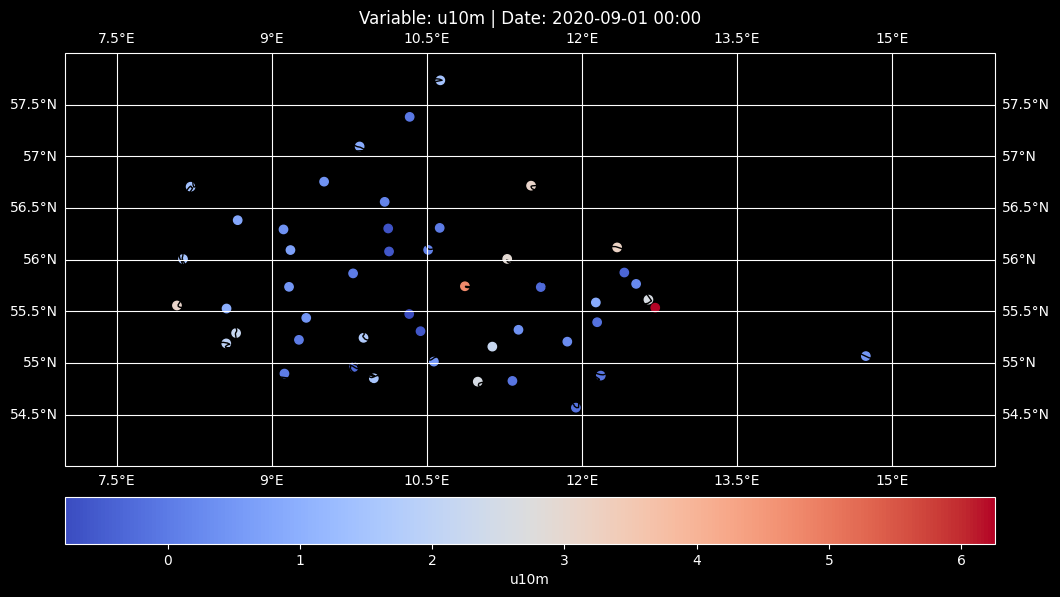

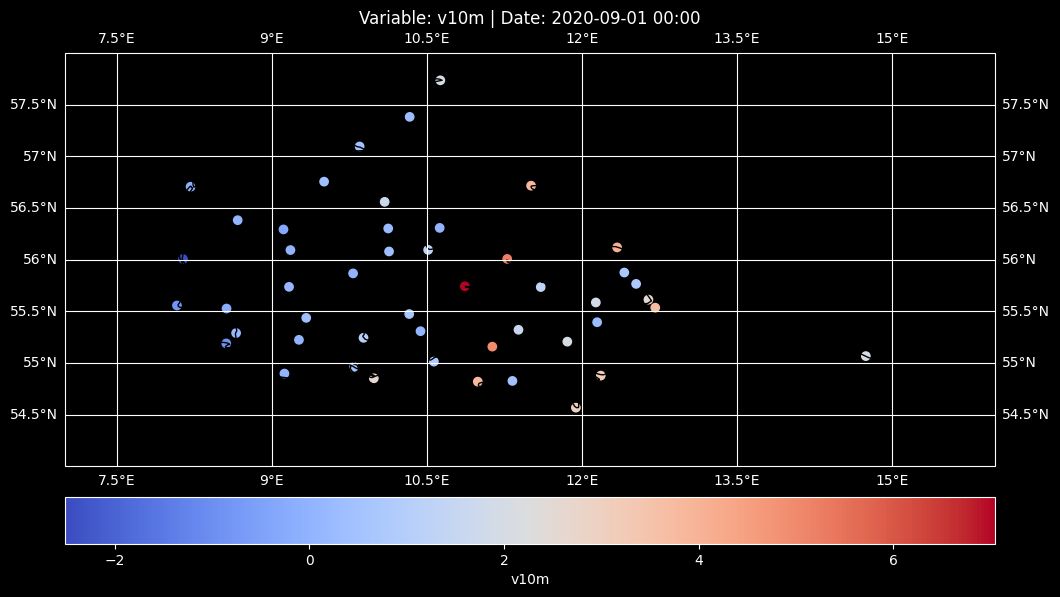

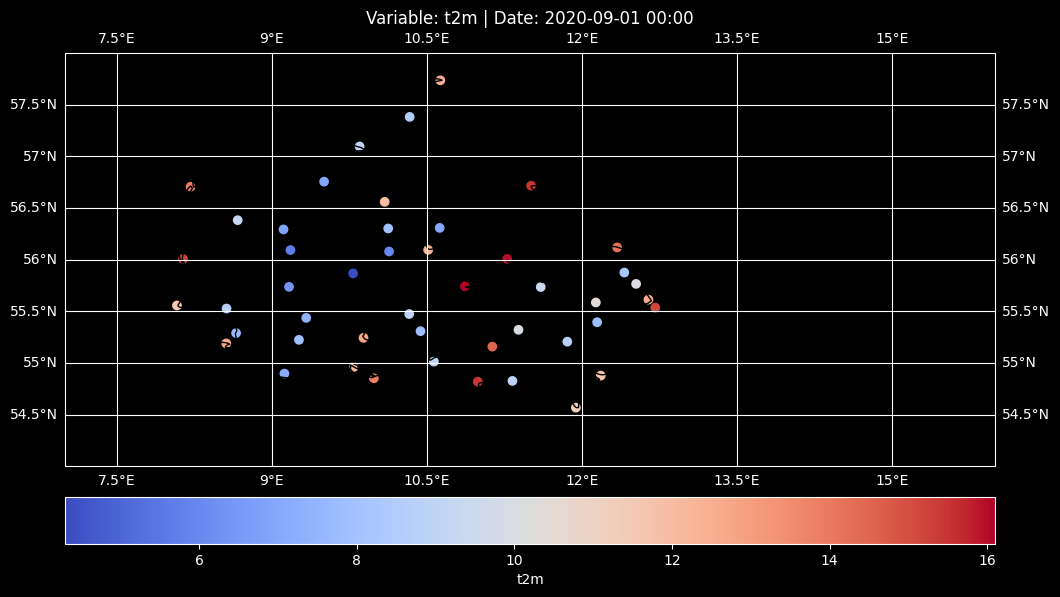

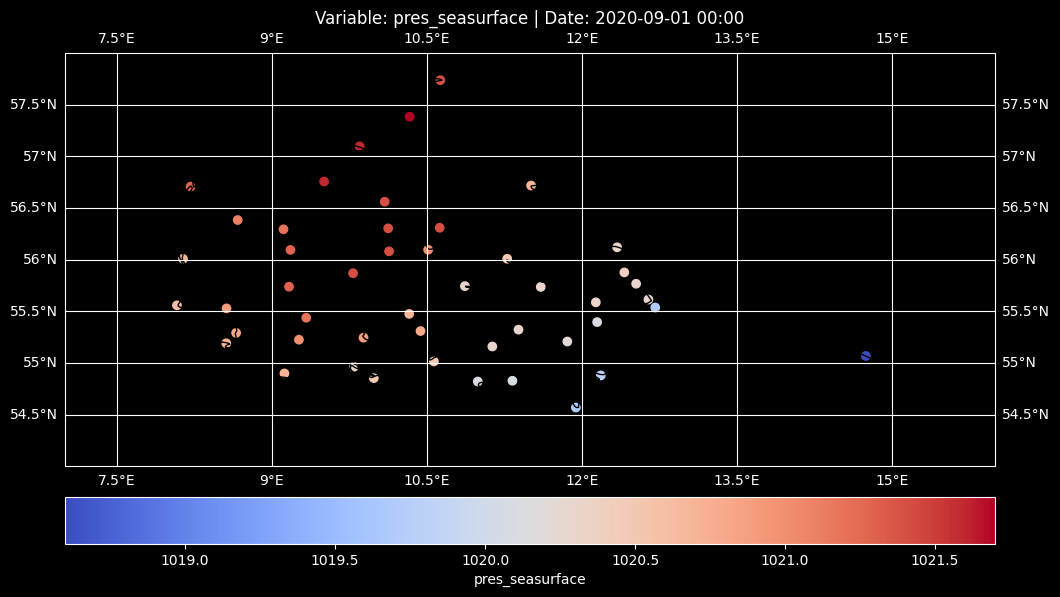

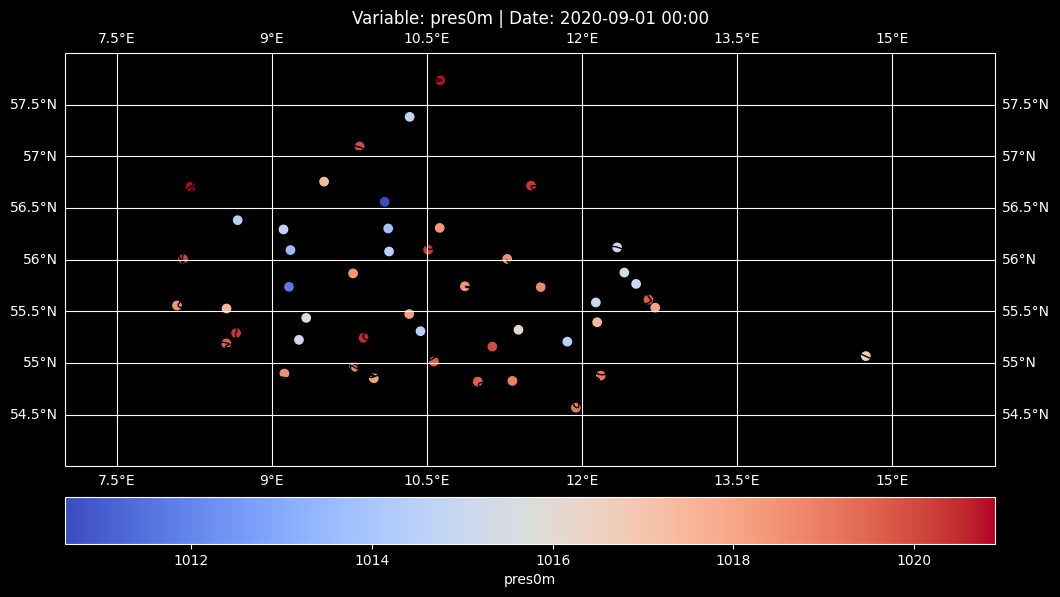

In [111]:
for var_plot in vars_plot:
    fig, ax = plt.subplots(
        figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    ax.set_extent([7, 16, 54, 58], crs=ccrs.PlateCarree())

    scatter = ax.scatter(
        ds_obs["lon"],
        ds_obs["lat"],
        c=ds_obs.isel(time=0)[var_plot],
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=True)

    cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label(var_plot)

    title = f"Variable: {var_plot} | Date: {formatted_date} {hour}:00"
    plt.title(title)
    plt.show()
    plt.close()

Visualization of the model data

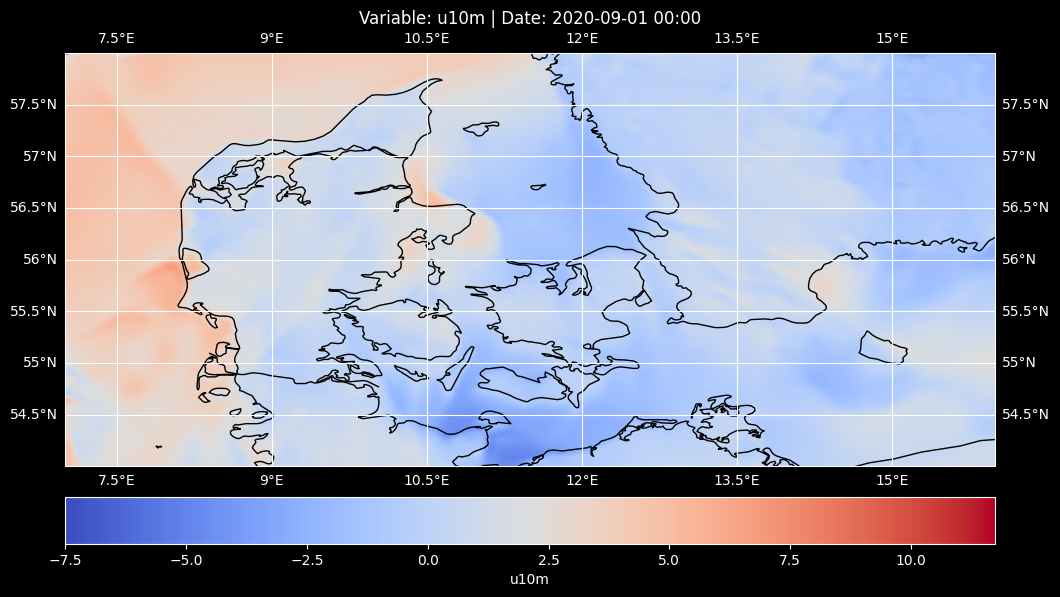

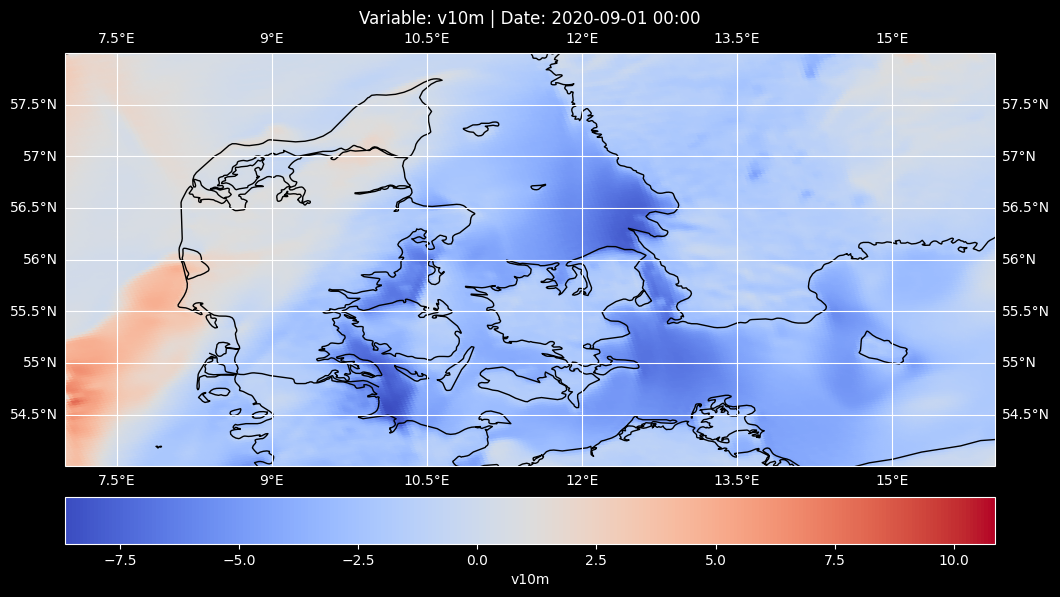

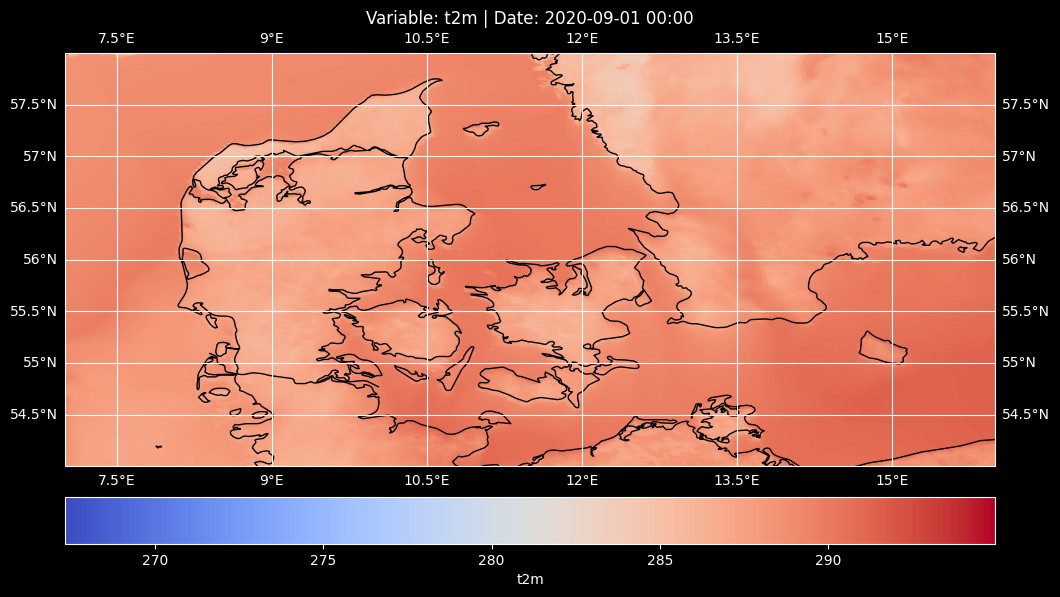

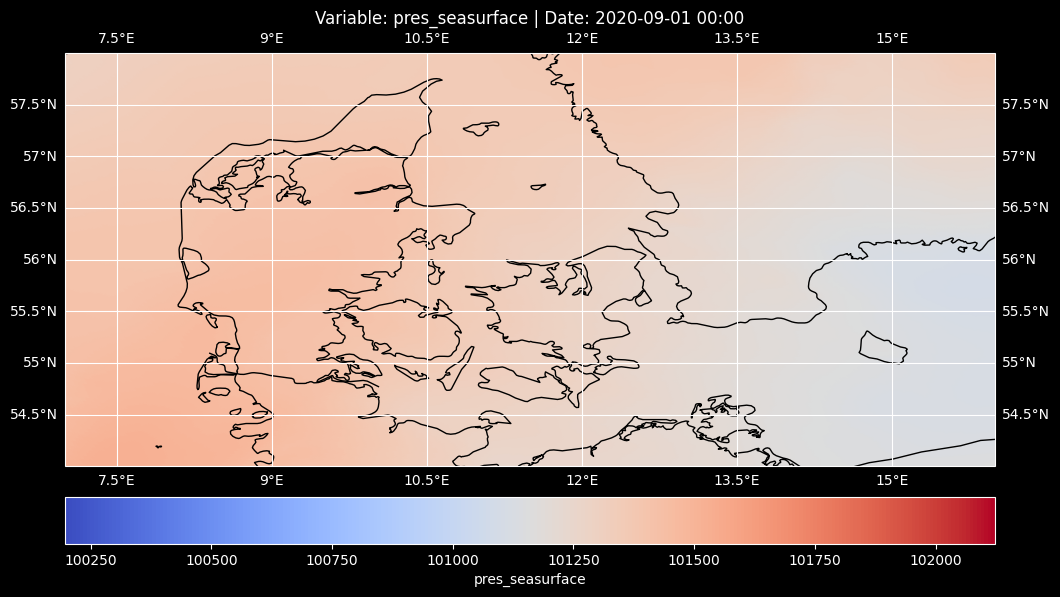

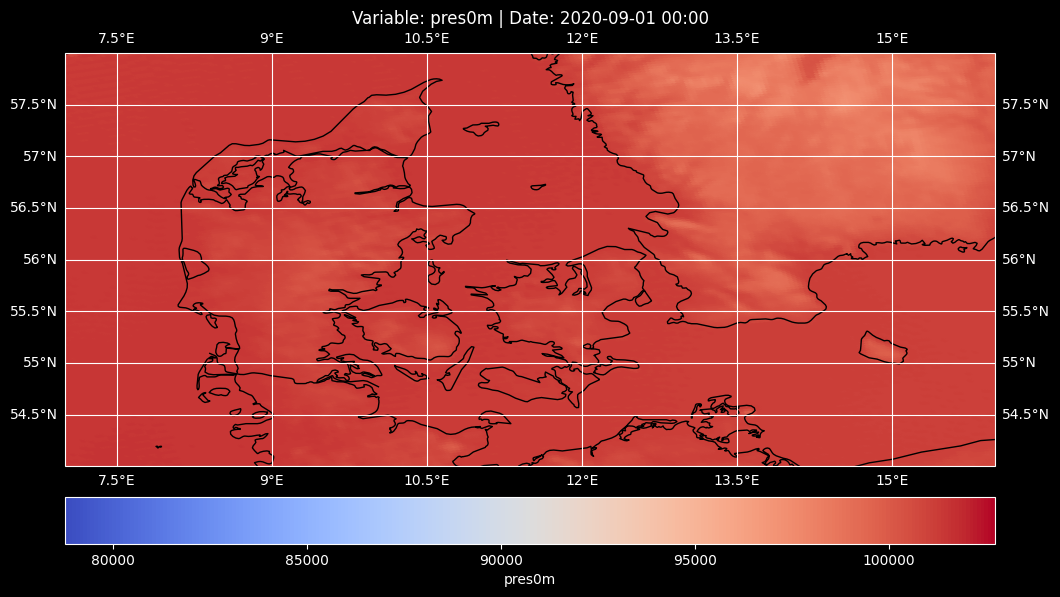

In [112]:
for var_plot in vars_plot:
    fig, ax = plt.subplots(
        figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    ax.set_extent([7, 16, 54, 58], crs=ccrs.PlateCarree())

    map = ax.scatter(
        ds_model["lon"],
        ds_model["lat"],
        c=ds_model.isel(time=0)[var_plot],
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=True)

    cbar = plt.colorbar(map, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label(var_plot)

    title = f"Variable: {var_plot} | Date: {formatted_date} {hour}:00"
    plt.title(title)
    plt.show()
    plt.close()

Interpolation of the model data (gridded) to the observation points.
There are many methods for this, but for this example we will use linear radial basis function interpolation.
For some variables like temperature and humidity vertical height adjustment is needed.

In [115]:
def nearest_neighbor_interpolate(ds_model, ds_obs, var_names):
    """
    Interpolate model data to observation locations using nearest neighbor approach.
    """
    # Extract coordinates
    lats_model = ds_model.lat.values.flatten()
    lons_model = ds_model.lon.values.flatten()
    points_model = np.column_stack((lats_model, lons_model))

    lats_obs = ds_obs.lat.values
    lons_obs = ds_obs.lon.values
    points_obs = np.column_stack((lats_obs, lons_obs))

    # Find nearest neighbors using KDTree
    tree = KDTree(points_model)
    indices = tree.query(points_obs, k=1)[1]

    result = {}
    for var in var_names:
        data_model = ds_model[var].values
        data_obs_shape = ds_obs[var].shape

        interpolated_data = np.zeros(data_obs_shape)
        for t in range(data_obs_shape[0]):
            data_slice = data_model[t].flatten()
            interpolated_data[t] = data_slice[indices]

        result[var] = interpolated_data

    return result


vars_to_interpolate = vars_plot
interpolated = rbf_interpolate_multi(ds_model, ds_obs, vars_to_interpolate)
ds_interpolated = xr.Dataset(
    {
        var: (["time", "stationId"], interpolated[var])
        for var in vars_to_interpolate
    },
    coords={
        "time": ds_obs.time,
        "stationId": ds_obs.stationId,
        "lat": ds_obs.lat,
        "lon": ds_obs.lon,
    },
)
ds_interpolated

<xarray.Dataset> Size: 194kB
Dimensions:          (time: 100, stationId: 48)
Coordinates:
  * time             (time) datetime64[ns] 800B 2020-09-01 ... 2020-09-13T09:...
  * stationId        (stationId) object 384B '06030' '06032' ... '06188' '06190'
    lat              (stationId) float64 384B 57.1 57.38 57.74 ... 55.88 55.07
    lon              (stationId) float64 384B 9.851 10.33 10.63 ... 12.41 14.75
Data variables:
    u10m             (time, stationId) float64 38kB 0.577 0.7992 ... 3.32 3.491
    v10m             (time, stationId) float64 38kB 2.187 0.7312 ... -2.329
    t2m              (time, stationId) float64 38kB 287.6 286.4 ... 288.7 287.8
    pres_seasurface  (time, stationId) float64 38kB 1.014e+05 ... 1.02e+05
    pres0m           (time, stationId) float64 38kB 1.013e+05 ... 1.019e+05

Visualization of the interpolated model data

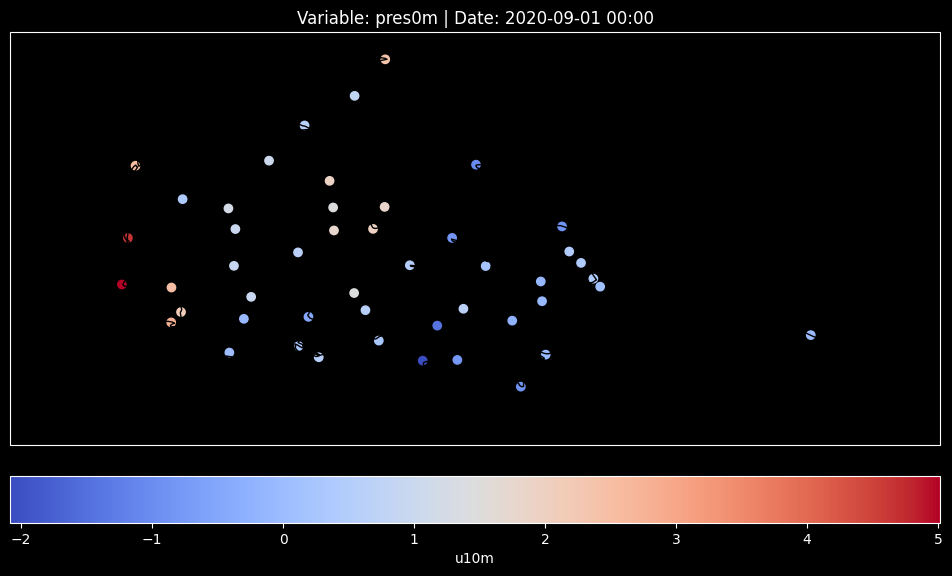

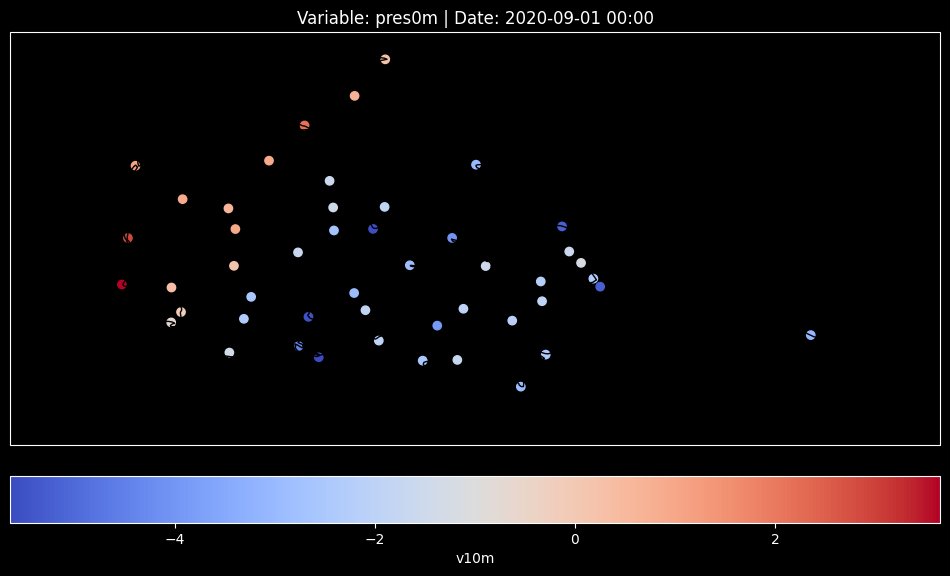

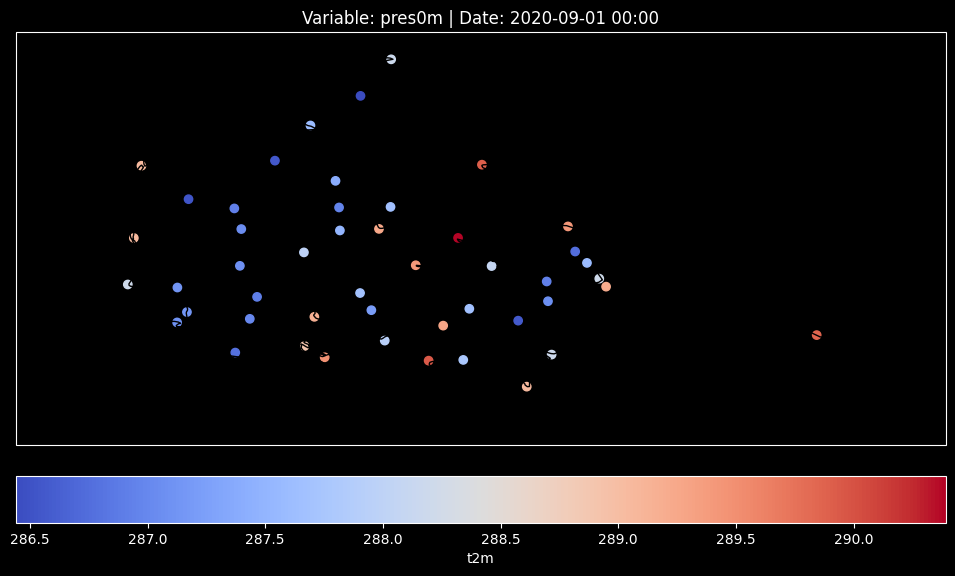

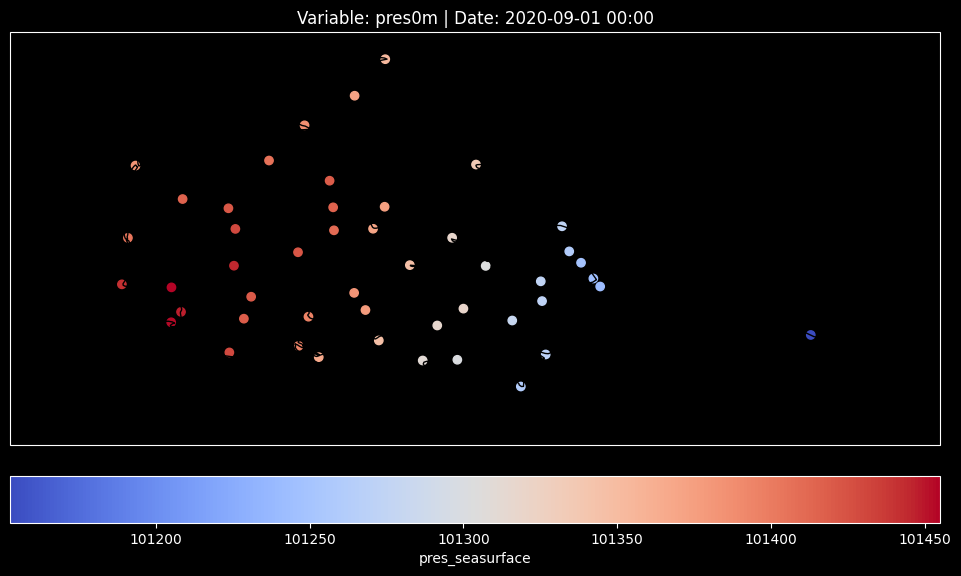

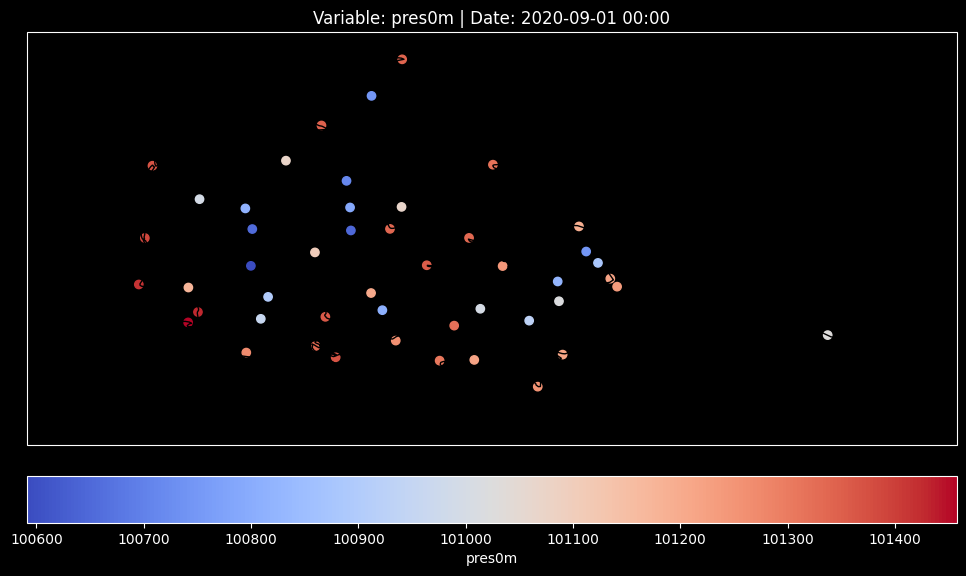

In [117]:
for var_plot in vars_plot:
    fig, ax = plt.subplots(
        figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()}
    )
    ax.set_extent([7, 16, 54, 58], crs=ccrs.PlateCarree())

    map = ax.scatter(
        ds_obs["lon"],
        ds_obs["lat"],
        c=interpolated[var_plot][0],
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)

    cbar = plt.colorbar(map, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label(var_plot)


    plt.title(title)
    plt.show()
    plt.close()

For the verification with scores the data must contain lat and lon as xarray dimensions.
Here we use masked arrays for this purpose. There might be a better way to do this.

In [123]:
def convert_2d_to_3d(ds_2d, station_coords):
    lats = station_coords.y.values
    lons = station_coords.x.values
    time_index = ds_2d.time.values

    ds_3d = xr.Dataset()
    for var in ds_2d.data_vars:
        data_3d = np.full((len(time_index), len(lats), len(lons)), np.nan)
        for i, station in enumerate(ds_2d.stationId.values):
            lat_idx = np.where(lats == station_coords.loc[station].y)[0][0]
            lon_idx = np.where(lons == station_coords.loc[station].x)[0][0]
            data_3d[:, lat_idx, lon_idx] = (
                ds_2d[var].sel(stationId=station).values
            )

        ds_3d[var] = xr.DataArray(
            data=data_3d,
            dims=["time", "lat", "lon"],
            coords={
                "time": time_index,
                "lat": ("lat", lats),
                "lon": ("lon", lons),
            },
        )

    return ds_3d


# Convert ds_obs
ds_obs_3d = convert_2d_to_3d(
    ds_obs, gdf.groupby("stationId")["geometry"].first()
)

# Convert ds_interpolated
ds_interpolated_3d = convert_2d_to_3d(
    ds_interpolated, gdf.groupby("stationId")["geometry"].first()
)

# Mask NaN values
masked_ds_obs_3d = ds_obs_3d.where(~np.isnan(ds_obs_3d), other=0)
masked_ds_interpolated_3d = ds_interpolated_3d.where(
    ~np.isnan(ds_interpolated_3d), other=0
)

Running the verification using the `scores` library.

In [126]:
def format_with_percent(val, col_name):
    """Format values with percentage for relative metrics"""
    if "Relative" in col_name:
        return f"{val:.6f}%"
    return f"{val:.4f}"


def calculate_all_metrics(ds_obs, ds_model, vars_plot=vars_plot, calc_relative=True):
    """Calculate a set of metrics for each variable in the given datasets."""
    metrics_dict = {}

    for var in vars_plot:
        y_true = ds_obs[var]
        y_pred = ds_model[var]

        # Calculate norms
        l1_norm = np.sum(np.abs(y_true.values))
        l2_norm = np.sqrt(np.sum(y_true.values**2))

        # Calculate metrics
        mae_val = mae(y_true, y_pred)
        rmse_val = rmse(y_true, y_pred)

        metrics_dict[var] = {
            "MAE": mae_val,
            "RMSE": rmse_val,
            "MSE": mse(y_true, y_pred),
            "Pearson R": pearsonr(y_true, y_pred),
            "Wasserstein Distance": wasserstein_distance(
                y_true.values.flatten(), y_pred.values.flatten()
            ),
        }

        if calc_relative:
            metrics_dict[var].update({
                "Relative L1 (%)": 100 * mae_val / l1_norm,
                "Relative L2 (%)": 100 * rmse_val / l2_norm,
            })

    # Create DataFrame with desired column order
    cols = [
        "MAE",
        "Relative L1 (%)",
        "RMSE",
        "Relative L2 (%)",
        "MSE",
        "Pearson R",
        "Wasserstein Distance",
    ]
    if not calc_relative:
        cols = [c for c in cols if "Relative" not in c]

    df = pd.DataFrame.from_dict(metrics_dict, orient="index")
    return df[cols]

In [127]:
# Calculate metrics
regular_metrics = calculate_all_metrics(
    masked_ds_obs_3d, masked_ds_interpolated_3d, calc_relative=True
)

# Create formatters dictionary
formatters = {
    col: lambda x, col=col: format_with_percent(x, col)
    for col in regular_metrics.columns
}

# Display tables with correct formatting
print("Regular Metrics (including relative):")
display(regular_metrics.style.format(formatters))



Regular Metrics (including relative):


,MAE,Relative L1 (%),RMSE,Relative L2 (%),MSE,Pearson R,Wasserstein Distance
u10m,0.1002,0.000500%,0.9487,0.267661%,0.9000,-0.2525,0.0892
v10m,0.0742,0.000636%,0.6939,0.314634%,0.4815,0.0355,0.0156
t2m,5.2346,0.007614%,37.7804,3.700350%,1427.3561,0.9720,5.2346
pres_seasurface,1927.3615,0.039927%,13909.7915,19.861560%,193482300.1716,0.9948,1927.3615
pres0m,1922.7900,0.039959%,13876.8443,19.877556%,192566807.3208,0.9948,1922.7900
